In [1]:
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.colors as pc
import plotly.graph_objects as go
from collections import Counter
import os
from joblib import Parallel, delayed
from tqdm import tqdm
from pathlib import Path

In [2]:
def load_item(project):
    owner, name = project.split('/')
    identifiers_path = f'/mnt/stobox/research-backup/rust-migration-thesis/migration-status/results/analysis/{owner}_{name}/identifiers.csv.gz'
    languages_path = f'/mnt/stobox/research-backup/rust-migration-thesis/migration-status/results/analysis/{owner}_{name}/languages.csv.gz'
    metadata_path = f'/mnt/stobox/in-repo-results-11-12-2025/{owner}_{name}/metadata.csv'

    with gzip.open(identifiers_path, 'rt') as f:
        identifiers = pd.read_csv(f, header=None, names=['i_before', 'i_after', 'lang_before', 'lang_after', 'num_moved', 'moved_len_mean', 'moved_len_std', 'num_common', 'common_len_mean', 'common_len_std', 'num_before', 'num_after'])

    with gzip.open(languages_path, 'rt') as f:
        languages = pd.read_csv(f, header=None, names=['i', 'lang', 'pct', 'code', 'blanks', 'comments'])

    metadata = pd.read_csv(metadata_path, on_bad_lines='skip')
    return (identifiers, languages, metadata)

def load_or_create_cache(base_path, filename, col_names):
    gz_path = f'{base_path}/{filename}.csv.gz'
    cache_path = f'{base_path}/{filename}.parquet'

    if os.path.exists(cache_path):
        return pd.read_parquet(cache_path)

    if not os.path.exists(gz_path):
        return None

    df = pd.read_csv(gz_path, compression='gzip', header=None, names=col_names)

    # try:
    #     df.to_parquet(cache_path, index=False)
    # except Exception:
    #     pass
    
    return df

def process_item(item, func):
    try:
        parts = item.split('_', 1)
        if len(parts) != 2: return None
        owner, name = parts

        base_path = f'/mnt/stobox/research-backup/rust-migration-thesis/migration-status/results/analysis/{owner}_{name}'

        identifiers = load_or_create_cache(
            base_path, 'identifiers',
            ['i_before', 'i_after', 'lang_before', 'lang_after', 'num_moved', 
             'moved_len_mean', 'moved_len_std', 'num_common', 'common_len_mean', 
             'common_len_std', 'num_before', 'num_after']
        )
        
        languages = load_or_create_cache(
            base_path, 'languages',
            ['i', 'lang', 'pct', 'code', 'blanks', 'comments']
        )

        if identifiers is None or languages is None:
            return None

        project_str = f'{owner}/{name}'
        identifiers['project'] = project_str
        identifiers['owner'] = owner
        identifiers['name'] = name
        
        languages['project'] = project_str
        languages['owner'] = owner
        languages['name'] = name

        return func(identifiers, languages)

    except Exception as e:
        return None

def run_func(func, n_jobs=-1):
    items = os.listdir('/mnt/stobox/research-backup/rust-migration-thesis/migration-status/results/analysis/')
    
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_item)(item, func) for item in tqdm(items)
    )

    results = [i for i in results if i is not None]

    return results

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.colors as pc

def plot(languages, identifiers, metadata, name):
    langs_keep = {'C', 'C++', 'Rust'}
    languages = languages[languages['lang'].isin(langs_keep)].copy()
    identifiers = identifiers[
        identifiers['lang_before'].isin(langs_keep) & identifiers['lang_after'].isin(langs_keep)
    ].copy()

    if languages.empty or identifiers.empty:
        print("No data for C, C++ or Rust")
        return
        
    # Standard GitHub linguist colors for these languages
    classic_colors = {
        'C': '#555555',     # Gray
        'C++': '#f34b7d',   # Pink
        'Rust': '#dea584'   # Tan/Orange
    }

    # --- Area Plot ---
    languages_pivot = languages.pivot_table(index='i', columns='lang', values='pct', fill_value=0)
    languages_pivot = languages_pivot.loc[:, (languages_pivot.max() > 0.003)]
    
    # Map classic colors to the area plot columns
    area_color_list = [classic_colors.get(lang, '#cccccc') for lang in languages_pivot.columns]
    
    languages_pivot.plot.area(figsize=(10, 6), legend=True, color=area_color_list)
    plt.xlabel('Time')
    plt.ylabel('Percentage of Code')
    plt.title(f'Programming languages used over time in {name}')
    plt.tight_layout()
    plt.ylim(0, languages_pivot.max().max() * 1.07)
    plt.xlim(0, languages_pivot.index.max())
    plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
    plt.show()

    # --- Sankey Diagram ---
    max_commit = identifiers['i_after'].max()
    TIMES = list(np.linspace(0, max_commit, 3, dtype=int))

    active_langs = set()
    for i in range(len(TIMES) - 1):
        t_start = TIMES[i]
        t_end = TIMES[i+1]
        step_data = identifiers[
            (identifiers['i_before'] == t_start) & 
            (identifiers['i_after'] == t_end) & 
            (identifiers['num_moved'] > 0)
        ]
        active_langs.update(step_data['lang_before'])
        active_langs.update(step_data['lang_after'])

    all_langs = sorted(list(active_langs))

    sources = []
    targets = []
    values = []
    node_labels = []
    node_colors = []
    link_colors = []
    node_map = {}

    for i in range(len(TIMES) - 1):
        t_start = TIMES[i]
        t_end = TIMES[i+1]
        
        step_data = identifiers[
            (identifiers['i_before'] == t_start) & 
            (identifiers['i_after'] == t_end) &
            (identifiers['num_moved'] > 0)
        ]
        
        step_summary = step_data.groupby(['lang_before', 'lang_after'])['num_moved'].sum().reset_index()
        
        for _, row in step_summary.iterrows():
            lang_src = row['lang_before']
            lang_tgt = row['lang_after']
            count = row['num_moved']

            src_key = (lang_src, t_start)
            tgt_key = (lang_tgt, t_end)
            
            if src_key not in node_map:
                node_map[src_key] = len(node_labels)
                node_labels.append(lang_src) 
                # Apply classic color here
                node_colors.append(classic_colors.get(lang_src, "grey"))
                
            if tgt_key not in node_map:
                node_map[tgt_key] = len(node_labels)
                node_labels.append(lang_tgt)
                # Apply classic color here
                node_colors.append(classic_colors.get(lang_tgt, "grey"))
                
            sources.append(node_map[src_key])
            targets.append(node_map[tgt_key])
            values.append(count)
            link_colors.append("lightgrey")

        # Add dummy links to maintain column alignment for active languages
        for lang in all_langs:
            src_key = (lang, t_start)
            tgt_key = (lang, t_end)

            if src_key not in node_map:
                node_map[src_key] = len(node_labels)
                node_labels.append("")
                node_colors.append("rgba(0,0,0,0)")

            if tgt_key not in node_map:
                node_map[tgt_key] = len(node_labels)
                node_labels.append("")
                node_colors.append("rgba(0,0,0,0)")

            sources.append(node_map[src_key])
            targets.append(node_map[tgt_key])
            values.append(1e-9)
            link_colors.append("rgba(0,0,0,0)")

    node_in_count = [0] * len(node_labels)
    node_out_count = [0] * len(node_labels)

    for s, t, v in zip(sources, targets, values):
        if v > 1e-8:
            node_out_count[s] += 1
            node_in_count[t] += 1

    for idx in range(len(node_labels)):
        if node_in_count[idx] == 0 and node_out_count[idx] == 0:
            node_labels[idx] = ""
            node_colors[idx] = "rgba(0,0,0,0)"

    for i in range(len(sources)):
        s = sources[i]
        t = targets[i]
        v = values[i]
        
        if v < 1e-8 or node_colors[s] == "rgba(0,0,0,0)" or node_colors[t] == "rgba(0,0,0,0)":
            link_colors[i] = "rgba(0,0,0,0)"

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color='black', width=0.0),
            label=node_labels,
            color=node_colors,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors
        )
    )])

    annotations = []
    shapes = []
    num_times = len(TIMES)

    for i, t in enumerate(TIMES):
        x_pos = i / (num_times - 1)
        closest_row_iloc = (metadata['index'] - t).abs().argmin()
        date_val = metadata['commit_time'].iloc[closest_row_iloc]
        date_str = pd.to_datetime(date_val).strftime('%Y-%m-%d')
        annotations.append(dict(
            x=x_pos, y=-0.15,
            xref="paper", yref="paper",
            text=date_str,
            showarrow=False,
            xanchor="center",
            yanchor="bottom",
            font=dict(size=15, color="black")
        ))
        shapes.append(dict(
            type="line",
            x0=x_pos, x1=x_pos,
            y0=-0.05, y1=1.05,
            xref="paper", yref="paper",
            line=dict(color="gray", width=1, dash="dot"),
            layer="below"
        ))

    fig.update_layout(
        font=dict(size=15),
        margin=dict(t=100),
        annotations=annotations,
        shapes=shapes
    )

    fig.show()

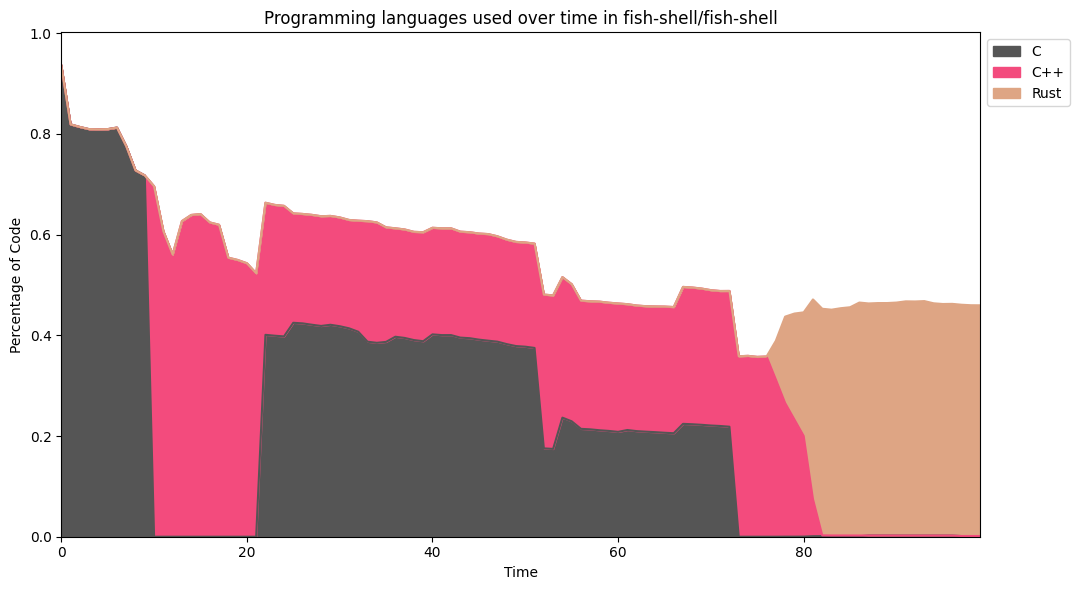

In [45]:
NAME = 'fish-shell/fish-shell'
identifiers, languages, metadata = load_item(NAME)
plot(languages, identifiers, metadata, NAME)

In [4]:
def plot_max_distribution(key, title, xlabel, xline):
    def get_max_num_moved(ids):
        mask = (ids["lang_after"] == "Rust") & (ids["lang_before"] != "Rust")
        if not mask.any():
            return None
        
        max_row = ids[mask].nlargest(1, key)
        return (max_row[key].values[0], max_row['lang_before'].values[0])

    results = run_func(lambda ids, langs: get_max_num_moved(ids))
    results = [x for x in results if x[0] > 0]

    all_values = [x[0] for x in results]
    
    lang_counts = Counter([x[1] for x in results])
    sorted_langs = [lang for lang, count in lang_counts.most_common()]

    stacked_values = []
    for lang in sorted_langs:
        vals = [x[0] for x in results if x[1] == lang]
        stacked_values.append(vals)

    plt.figure(figsize=(10, 6))
    bins = np.logspace(np.log10(np.min(all_values)), np.log10(np.max(all_values)+1), 20)
    plt.hist(stacked_values, bins=bins, stacked=True, edgecolor='black', label=sorted_langs)
    # plt.axvline(xline, color='red', linewidth=2)
    plt.xscale('log')
    plt.xlabel(xlabel)
    plt.ylabel('Number of projects')
    plt.title(title)
    plt.grid(True, which='both', ls='--', alpha=0.4)
    plt.legend(title="From Language", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the plots
plot_max_distribution('num_moved', 'Distribution of highest movement to Rust', 'Number of identifiers moved to Rust (log scale)', 71)
plot_max_distribution('num_common', 'Distribution of highest common identifiers with Rust', 'Number of common identifiers with Rust (log scale)', 124)

  0%|          | 0/6474 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
RESULTS_FOLDER = Path('/mnt/stobox/in-repo-results-11-12-2025')

data = []
projects = [p for p in RESULTS_FOLDER.iterdir() if p.is_dir()]

for project in tqdm(projects, desc="Processing projects", unit="project"):
    metadata_path = project / 'metadata.csv'

    try:
        df = pd.read_csv(metadata_path, usecols=['commit_time'], on_bad_lines='skip')
        commit_times = pd.to_datetime(df['commit_time'], errors='coerce', utc=True).dropna()
        between_times = commit_times.sort_values().diff().dt.total_seconds().dropna() / (60 * 60 * 24)

        if not between_times.empty:
            data.append({
                'mean': between_times.mean(),
                'min': between_times.min(),
                'max': between_times.max()
            })

    except Exception as e:
        print(f"Error processing {metadata_path.name}: {e}")
        continue

res_df = pd.DataFrame(data, columns=['mean', 'min', 'max'])

if res_df.empty:
    print("No valid commit-time gaps found to plot.")
else:
    fig, ax = plt.subplots(figsize=(7, 5))
    box_props = dict(linestyle='-', linewidth=1.5, color='#2c3e50')
    median_props = dict(linestyle='-', linewidth=2, color='#e74c3c')

    res_df[['mean', 'min', 'max']] = res_df[['mean', 'min', 'max']].apply(pd.to_numeric, errors='coerce')
    res_df = res_df.dropna(subset=['mean', 'min', 'max'])

    if res_df.empty:
        print("No numeric commit-time gap values available after cleaning.")
    else:
        res_df.boxplot(
            column=['mean', 'min', 'max'],
            ax=ax,
            showfliers=False,
            boxprops=box_props,
            medianprops=median_props,
            whiskerprops=box_props,
            capprops=box_props
        )
        # plt.yscale('log')
        plt.ylabel('Days between commits')
        plt.title('Distribution of commit-time gaps across projects')
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()